   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

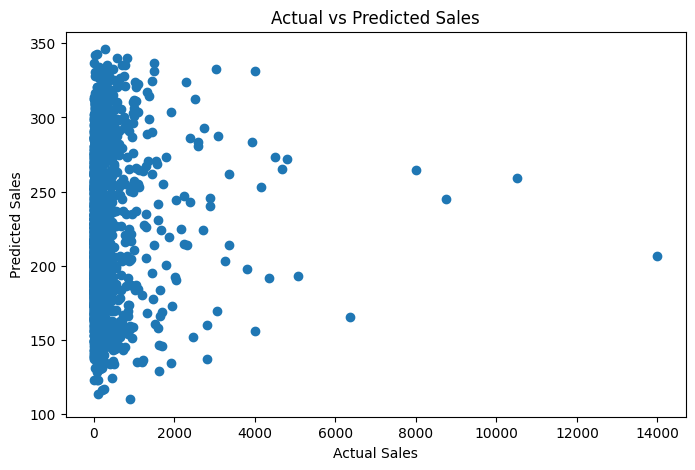

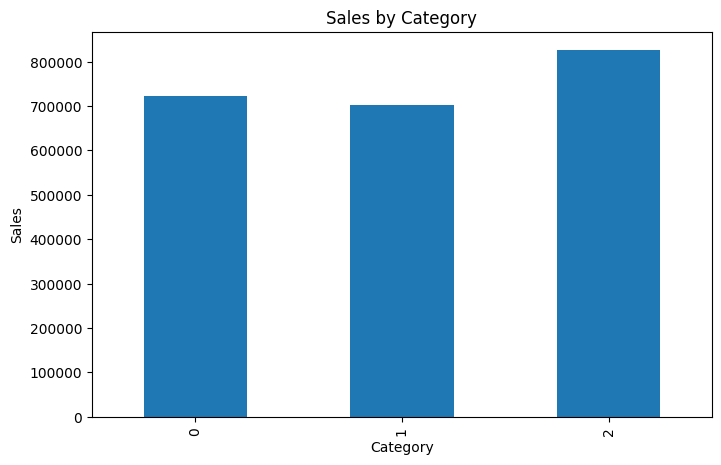

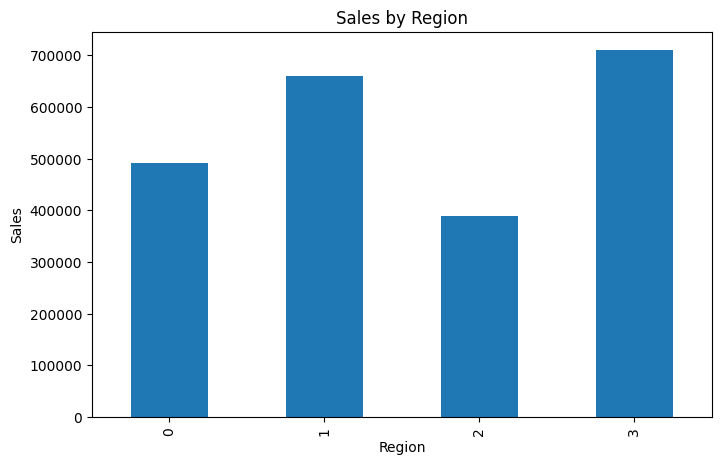

In [4]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset

df = pd.read_csv("/content/Superstore.csv")

# Display First Rows

print(df.head())

# Dataset Information

print(df.info())

# Missing Values

print(df.isnull().sum())

# Remove Missing Values

df.dropna(inplace=True)

# Encode Categorical Columns

encoder = LabelEncoder()

categorical_columns = ['Ship Mode','Segment','Country','City','State','Region','Category','Sub-Category']

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# Convert Date Columns

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

df['OrderYear'] = df['Order Date'].dt.year
df['OrderMonth'] = df['Order Date'].dt.month
df['ShipDays'] = (df['Ship Date'] - df['Order Date']).dt.days

# Remove Unnecessary Columns

df.drop(['Order ID','Customer ID','Customer Name','Product ID',
         'Product Name','Postal Code','Order Date','Ship Date'],axis=1,inplace=True)

# Features and Target

X = df.drop("Sales",axis=1)
y = df["Sales"]

# Train Test Split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

# Train Model

model = LinearRegression()

model.fit(X_train,y_train)

# Prediction

y_pred = model.predict(X_test)

# Evaluation

print("MAE:",mean_absolute_error(y_test,y_pred))

print("MSE:",mean_squared_error(y_test,y_pred))

print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

print("R2 Score:",r2_score(y_test,y_pred))

# Actual vs Predicted

plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

# Sales by Category

plt.figure(figsize=(8,5))
df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

# Sales by Region

plt.figure(figsize=(8,5))
df.groupby("Region")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()